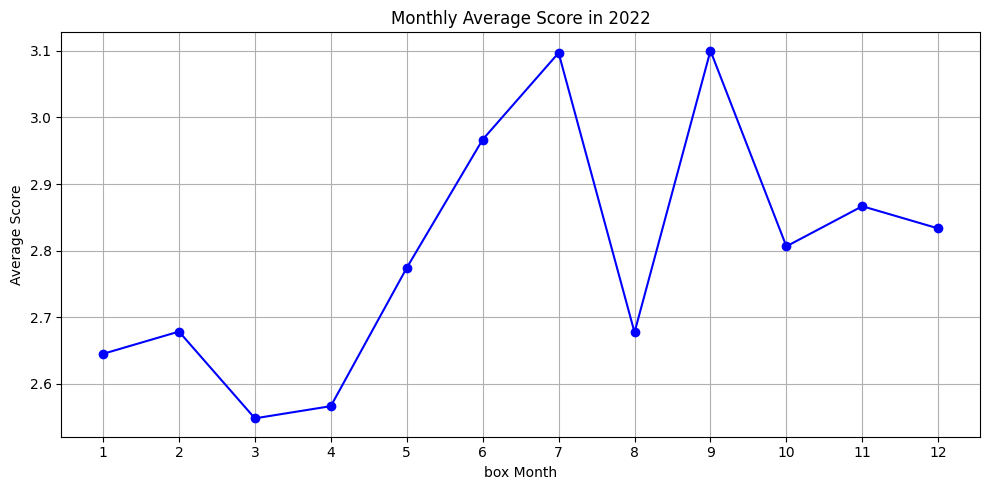

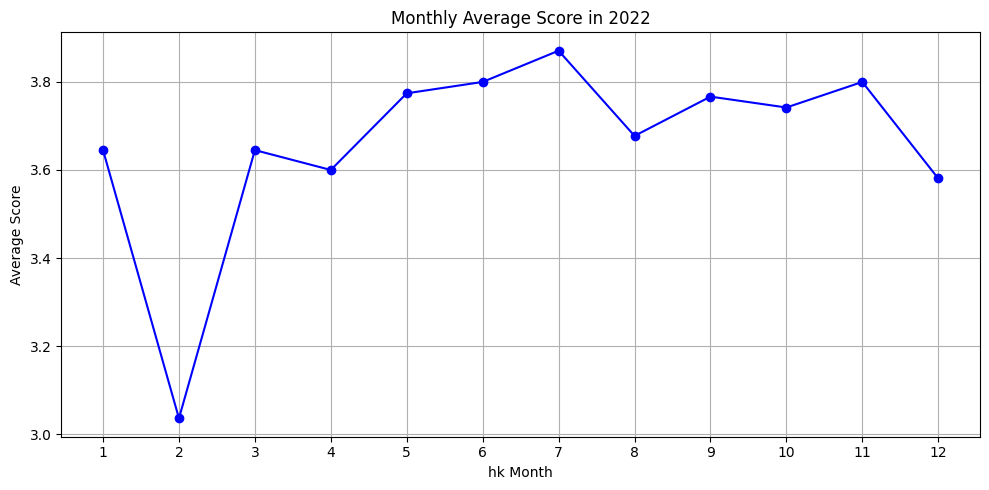

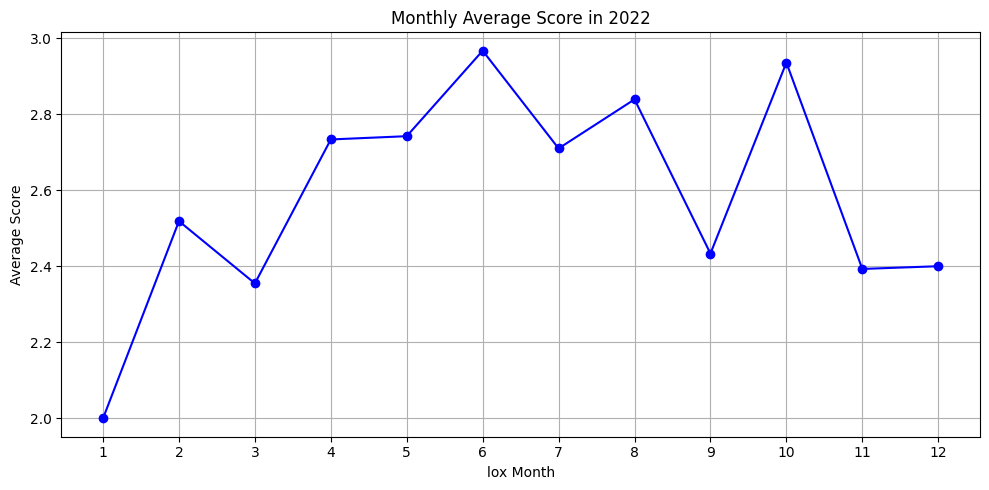

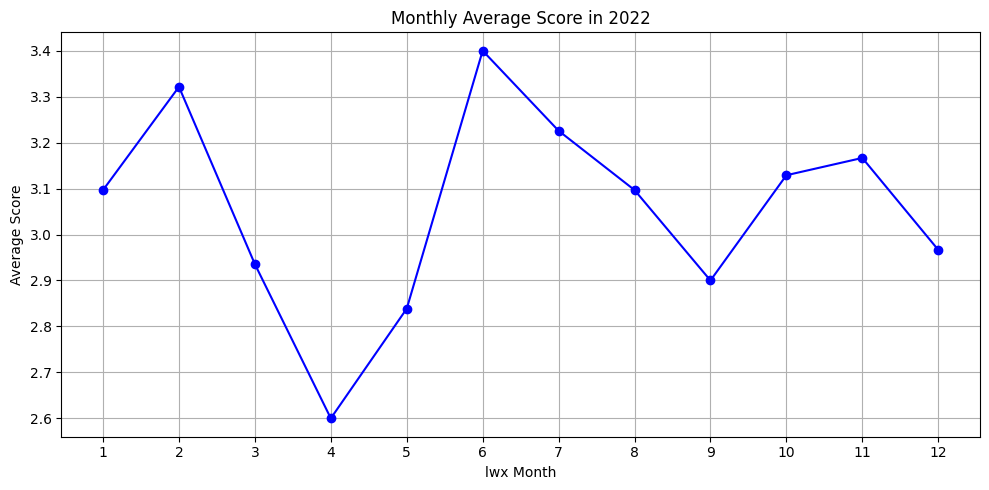

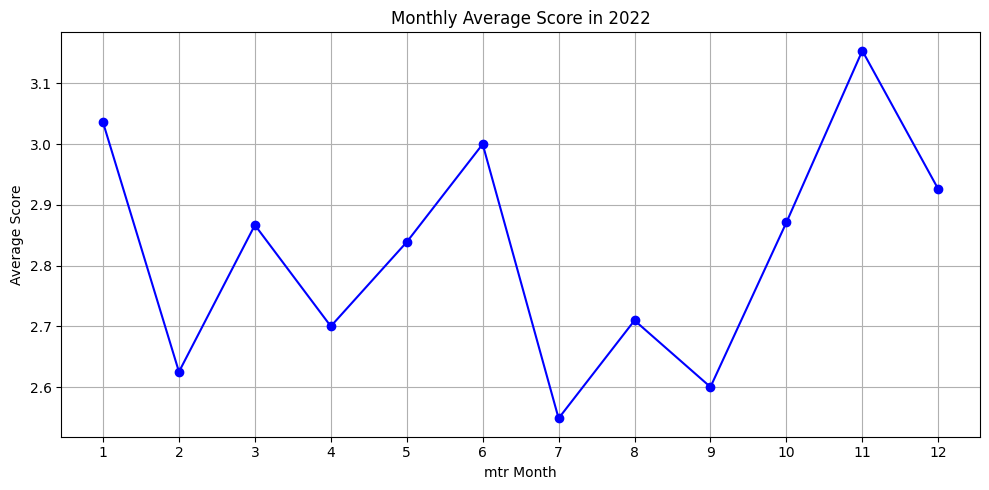

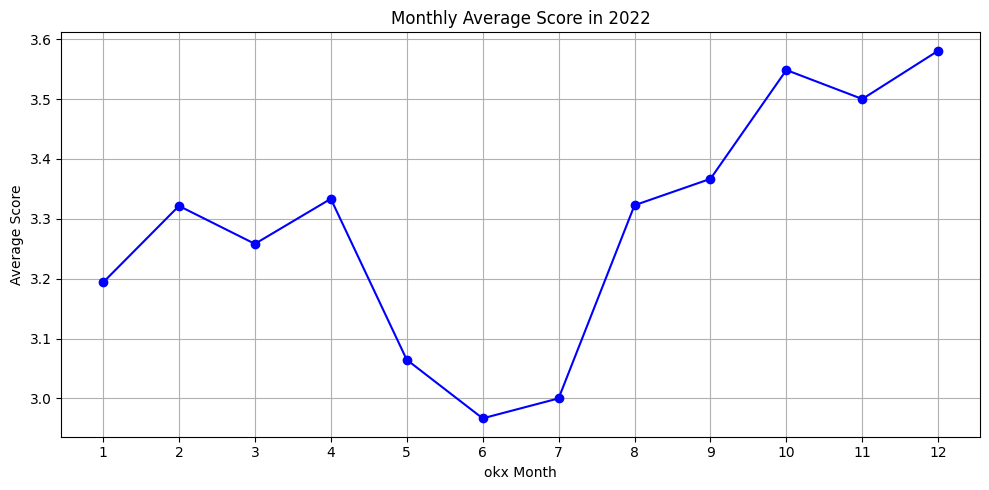

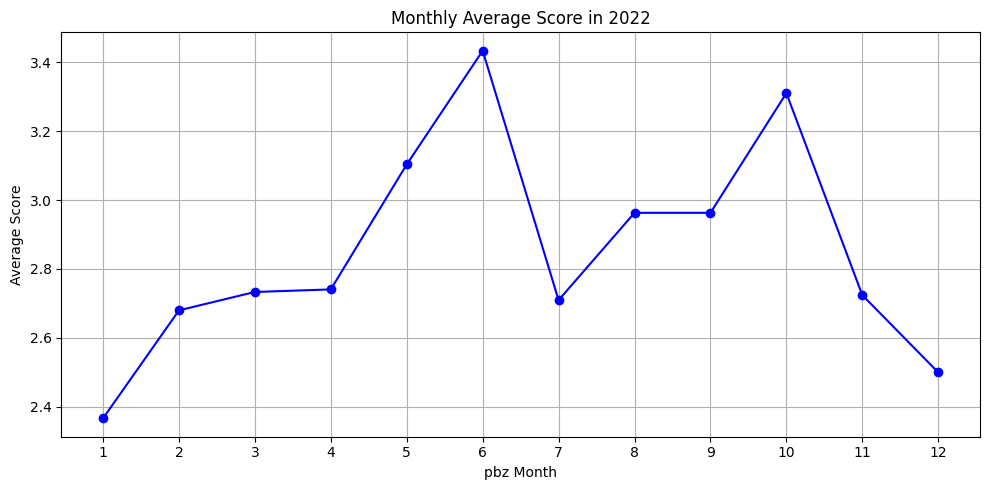

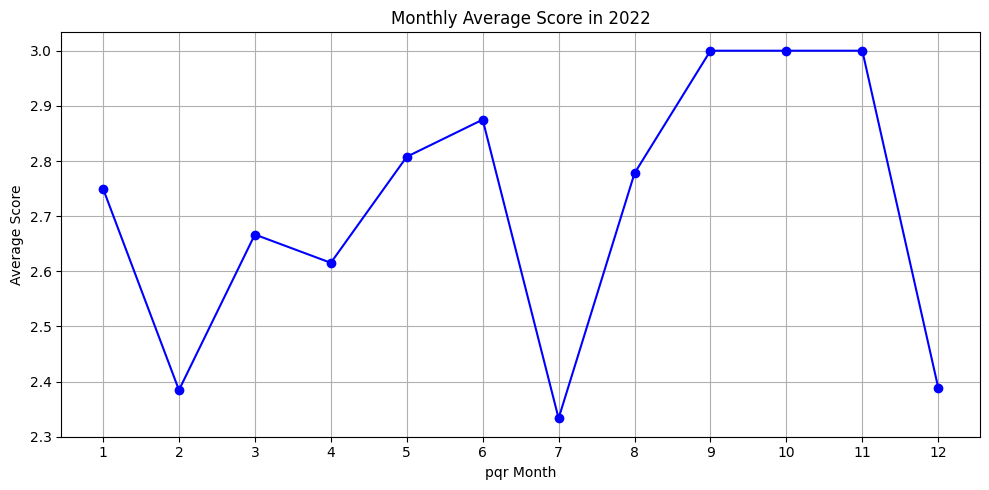

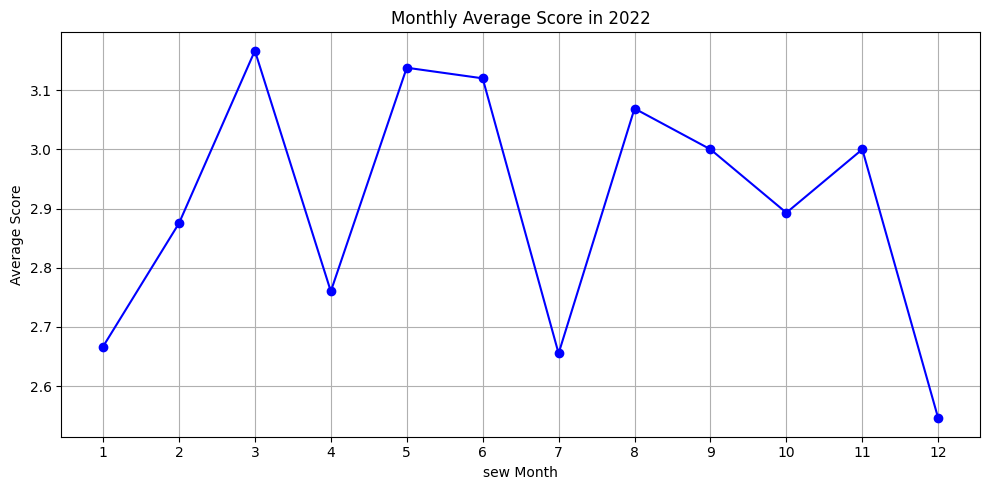

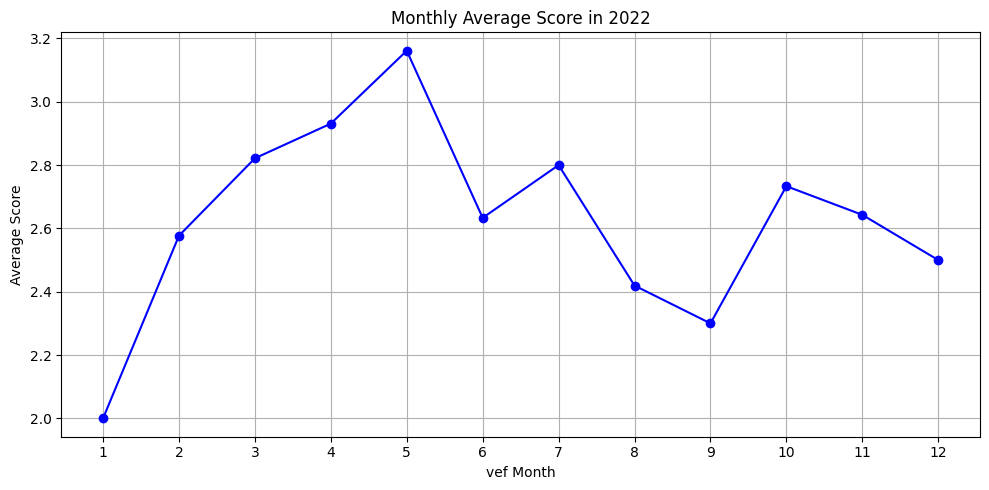

In [7]:
import json
import os
from collections import defaultdict
from datetime import datetime
import matplotlib.pyplot as plt

# 设置 JSON 文件路径（替换为你的文件路径）
for area in ['box','hk','lox','lwx','mtr','okx','pbz','pqr','sew','vef']:
    json_path = f"/data1/zzn/json/datajson/result_correctness/result_qwen_{area}_single.json"

    # 加载 JSON 数据
    with open(json_path, "r") as f:
        data = json.load(f)

    # 初始化每月的 score 列表
    monthly_scores = defaultdict(list)

    # 遍历每条记录
    for key, value in data.items():
        try:
            date_str = key.split("T")[0]  # 提取日期部分 "2022-01-01"
            date_obj = datetime.strptime(date_str, "%Y-%m-%d")
            if date_obj.year == 2022:
                month = date_obj.month
                score = value[0].get("score", None)
                if score is not None:
                    monthly_scores[month].append(score)
        except Exception as e:
            print(f"跳过无效项 {key}: {e}")

    # 计算每月平均 score
    monthly_avg_scores = {
        month: sum(scores) / len(scores) if scores else 0
        for month, scores in sorted(monthly_scores.items())
    }

    # 构造完整的 12 个月份列表
    months = list(range(1, 13))
    avg_scores = [monthly_avg_scores.get(m, 0) for m in months]

    # 可视化
    plt.figure(figsize=(10, 5))
    plt.plot(months, avg_scores, marker='o', linestyle='-', color='blue')
    plt.xticks(months)
    plt.xlabel(f"{area} Month")
    plt.ylabel("Average Score")
    plt.title("Monthly Average Score in 2022")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


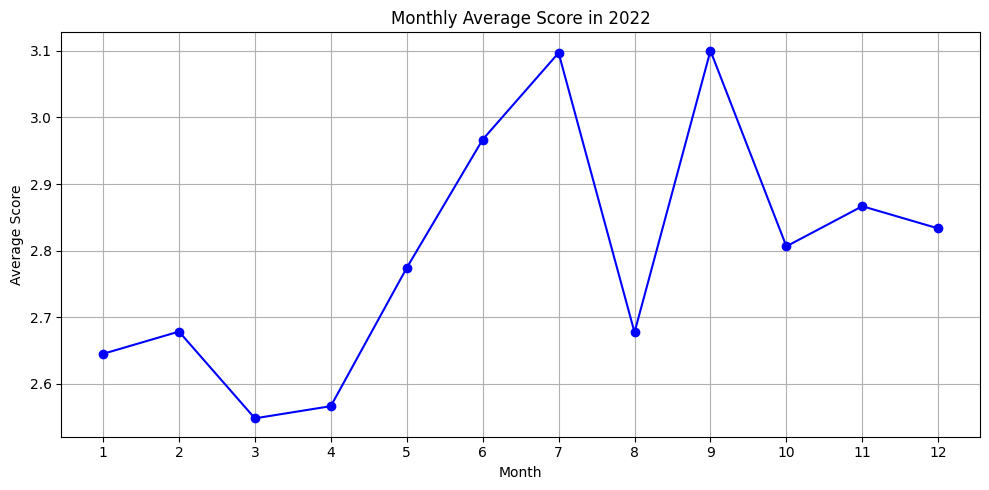

In [5]:
import json
import os
from collections import defaultdict
from datetime import datetime
import matplotlib.pyplot as plt

# 设置 JSON 文件路径（替换为你的文件路径）
json_path = "/data1/zzn/json/datajson/result_correctness/result_qwen_box_single.json"

# 加载 JSON 数据
with open(json_path, "r") as f:
    data = json.load(f)

# 初始化每月的 score 列表
monthly_scores = defaultdict(list)

# 遍历每条记录
for key, value in data.items():
    try:
        date_str = key.split("T")[0]  # 提取日期部分 "2022-01-01"
        date_obj = datetime.strptime(date_str, "%Y-%m-%d")
        if date_obj.year == 2022:
            month = date_obj.month
            score = value[0].get("score", None)
            if score is not None:
                monthly_scores[month].append(score)
    except Exception as e:
        print(f"跳过无效项 {key}: {e}")

# 计算每月平均 score
monthly_avg_scores = {
    month: sum(scores) / len(scores) if scores else 0
    for month, scores in sorted(monthly_scores.items())
}

# 构造完整的 12 个月份列表
months = list(range(1, 13))
avg_scores = [monthly_avg_scores.get(m, 0) for m in months]

# 可视化
plt.figure(figsize=(10, 5))
plt.plot(months, avg_scores, marker='o', linestyle='-', color='blue')
plt.xticks(months)
plt.xlabel("Month")
plt.ylabel("Average Score")
plt.title("Monthly Average Score in 2022")
plt.grid(True)
plt.tight_layout()
plt.show()
